# Online Course Recommendation System

**Author:** Chandoj Rishikesh Chary  
**Domain:** Machine Learning / Recommender Systems  

---

## Project Overview

This project builds an **Online Course Recommendation System** that suggests relevant courses to learners based on their interests, past enrollments, and engagement levels.

### Dataset
- **Size:** 1,00,000 rows × 14 columns
- **Courses:** 20 unique courses | **Users:** ~40,000 unique users
- **Key features:** `user_id`, `course_name`, `instructor`, `difficulty_level`, `rating`, `time_spent_hours`, `feedback_score`, `previous_courses_taken`, `course_duration_hours`, `course_price`, `certification_offered`, `study_material_available`

### Models Built
| # | Model | Approach |
|---|---|---|
| 1 | Content-Based Filtering (CBF) | Cosine similarity on course metadata |
| 2 | SVD | Matrix factorization (Collaborative Filtering) |
| 3 | KNN (Item-Based) | Item similarity (Collaborative Filtering) |
| 4 | **Hybrid** | Weighted blend of all three models |

### Notebook Structure
1. EDA & Data Preprocessing
2. Feature Selection
3. Model Building (CBF → SVD → KNN → Hybrid)
4. Evaluation (RMSE, MAE, Precision, Recall, NDCG @5)
5. Visualisations & Conclusion


# Business Objective: Online Course Recommendation System Dataset V2
## Problem Statement
- The goal of this dataset is to build an online course recommendation system that suggests relevant courses to learners based on their interests, past enrollments, and engagement levels.
- The dataset includes course ratings, instructor information, previous learning history, study material availability, and certification offerings, making it suitable for recommendation models using collaborative filtering, content-based filtering, or hybrid approaches.

# 1. EDA

In [1]:
# Import the pandas library for data manipulation, DataFrame creation, and analysis
import pandas as pd

# Import numpy for numerical operations and handling arrays efficiently
import numpy as np

# Import matplotlib's pyplot module for creating static and interactive visualizations
import matplotlib.pyplot as plt

# Import seaborn for creating attractive, statistical graphics built on top of matplotlib
import seaborn as sns

# Import StandardScaler from scikit-learn to normalize continuous numerical features
from sklearn.preprocessing import StandardScaler

# Import LabelEncoder from scikit-learn to convert binary text categories into numerical values
from sklearn.preprocessing import LabelEncoder

# Import warnings to suppress all warnings while running the code by using Python's built-in warnings module
import warnings
warnings.filterwarnings('ignore')

# PART 1: DATA PREPROCESSING
# Load the dataset from a excel file into a pandas DataFrame
df = pd.read_excel('online_course_recommendation.xlsx')

# Displays the first 5 rows along with column and their respective values
display(df.head())

C:\Users\rishi\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\rishi\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [2]:
# Shape of the dataframe(rows,columns)
print("Shape of the dataframe:",df.shape) 

# Check the data types, non-null counts, and memory usage
print("\nDataFrame's Information:") 
display(df.info())

# Summary Statistics
print("\nDataFrame's Descriptive Statistics:")
display(df.describe(include='all')) # Gives mean, std, min, max, and different quartile values

Shape of the dataframe: (100000, 14)

DataFrame's Information:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  str    
 3   instructor                100000 non-null  str    
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  str    
 6   difficulty_level          100000 non-null  str    
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  str    
 12  time_spent_hours          100000 non-null  float6

None


DataFrame's Descriptive Statistics:


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
count,100000.000000,100000.000000,100000,100000,100000.00000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000.000000,100000.000000
unique,NaN,NaN,20,20,NaN,2,3,NaN,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,Networking and System Administration,Jessica Martinez,NaN,Yes,Beginner,NaN,NaN,NaN,NaN,Yes,NaN,NaN
freq,NaN,NaN,5107,5092,NaN,70059,49877,NaN,NaN,NaN,NaN,85147,NaN,NaN
mean,24935.663570,5006.863560,NaN,NaN,52.38354,NaN,NaN,3.959859,25052.822850,261.073369,0.746865,NaN,20.691054,4.992670
std,14406.960108,2882.085456,NaN,NaN,27.42347,NaN,NaN,0.729958,14388.188356,139.013758,0.143683,NaN,13.669148,2.237259
min,1.000000,1.000000,NaN,NaN,5.00000,NaN,NaN,1.000000,50.000000,20.000000,0.092000,NaN,1.000000,0.000000
25%,12487.750000,2523.000000,NaN,NaN,28.60000,NaN,NaN,3.500000,12583.750000,140.100000,0.649000,NaN,9.900000,3.000000
50%,24793.500000,5012.000000,NaN,NaN,52.40000,NaN,NaN,4.000000,25057.500000,262.310000,0.750000,NaN,19.920000,5.000000
75%,37382.250000,7502.000000,NaN,NaN,76.10000,NaN,NaN,4.500000,37522.000000,381.702500,0.851000,NaN,30.080000,6.000000


In [3]:
# Check for missing values
print("Null Count:")
display(df.isnull().sum())
# display(df.isna().sum()) # Can use df.isna() also to know the null values

# Check for Duplicate rows 
print("\nDuplicate Rows Count:",df.duplicated().sum())

Null Count:


user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64


Duplicate Rows Count: 0


In [4]:
# Check for unique values in all the columns using the for loop
for col in df.columns:
    print(f"\nUnique Values in {col}:", df[col].unique()) # Identify the unique value every column has


Unique Values in user_id: [15796   861 38159 ... 14669 49654 12929]

Unique Values in course_id: [9366 1928 9541 ... 4445 4004 5636]

Unique Values in course_name: <ArrowStringArray>
[                     'Python for Beginners',
           'Cybersecurity for Professionals',
          'DevOps and Continuous Deployment',
           'Project Management Fundamentals',
               'Ethical Hacking Masterclass',
      'Networking and System Administration',
      'Personal Finance and Wealth Building',
 'Blockchain and Decentralized Applications',
                 'Graphic Design with Canva',
            'Fitness and Nutrition Coaching',
                   'Public Speaking Mastery',
             'Photography and Video Editing',
                 'Advanced Machine Learning',
               'Game Development with Unity',
                'Cloud Computing Essentials',
         'Mobile App Development with Swift',
           'Data Visualization with Tableau',
       'Stock Market and Trading S

In [5]:
# Drop low-signal feature
df.drop(columns=['enrollment_numbers'], inplace=True)

# Encode binary columns
le = LabelEncoder()
df['certification_offered']    = le.fit_transform(df['certification_offered'])
df['study_material_available'] = le.fit_transform(df['study_material_available'])

# Ordinal encode difficulty (preserves meaningful order)
difficulty_map = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
df['difficulty_level'] = df['difficulty_level'].str.strip().map(difficulty_map)

# Scale continuous features
scaler = StandardScaler()
df[['course_duration_hours', 'course_price', 'time_spent_hours']] = scaler.fit_transform(
    df[['course_duration_hours', 'course_price', 'time_spent_hours']]
)

# Engagement-weighted final_rating
def minmax_5(s): return 1 + (s - s.min()) / (s.max() - s.min()) * 4

df['time_norm']       = minmax_5(df['time_spent_hours'])
df['feedback_norm']   = minmax_5(df['feedback_score'])
df['user_confidence'] = np.clip(df['previous_courses_taken'] / 10.0, 0, 1)

global_mean = (0.7*df['rating'] + 0.2*df['time_norm'] + 0.1*df['feedback_norm']).mean()
df['final_rating'] = (
    df['user_confidence'] * (0.7*df['rating'] + 0.2*df['time_norm'] + 0.1*df['feedback_norm']) +
    (1 - df['user_confidence']) * global_mean
).clip(1, 5)

print(f"Dataset ready: {df.shape}")
display(df[['user_id','course_name','rating','final_rating','difficulty_level']].head())

Dataset ready: (100000, 17)


,user_id,course_name,rating,final_rating,difficulty_level
0,15796,Python for Beginners,5.0,3.838017,0
1,861,Cybersecurity for Professionals,4.3,3.844988,0
2,38159,DevOps and Continuous Deployment,3.9,3.659692,0
3,44733,Project Management Fundamentals,3.1,3.256643,0
4,11285,Ethical Hacking Masterclass,2.8,3.107972,0


# Data Preprocessing Analysis:

**1. Overall Shape & DataFrame Information:**
- The dataset has 100,000 i.e 1 lakh rows and 14 columns.
- Every single column shows 100000 non-null values. This means there is absolutely no missing data in this dataset to impute or drop.
- **NOTE:** `previous_courses` taken has values like 0 which will be considered as valid data and not null since a new user who has never taken a course might require completely different recommendation stratergy like suggesting popular beginner courses whereas an experienced user who has already taken a course might require different courses recommendations like intermediate and advanced.
- Text/categorical columns are object, continuous numerical values are float64, and discrete counts/IDs are int64.
- There are no duplicate rows in the dataset which means every single user-course interaction logged in this dataset is a distinct, unique event.

**2. Descriptive Statistics:**

* **2.1. Categorical Insights:**
   - There are exactly 20 unique `course_name` values and 20 unique `instructor` values. This highly suggests a 1-to-1 relationship i.e. each instructor likely teaches exactly one specific course.
    - Networking and System Administration is the most frequently occurring course in the dataset (5,107 entries noted via freq row), taught by Jessica Martinez.
    - Out of 3 unique difficulty levels, Beginner is the most common, making up almost exactly half of the dataset (49,877 entries).
    - 70% of the course interactions (70,059) offer a certification (certification_offered top value is 'Yes'). 85% of them provide study materials (study_material_available top value is 'Yes').

* **2.2. Numerical Insights:**
    - The `rating` ranges from 1.0 to 5.0, with a strong mean of ~3.96. The 50th percentile (median) is 4.0, indicating that most users are satisfied with their courses.
    - `course_duration_hours` ranges from 5 to 100 hours, with a mean of ~52 hours. `course_price` ranges from 20 to 500, with a mean of ~261. Both of these distributions seem very evenly spread out (mean and median are almost identical).
    - While the average course duration is ~52 hours, the average `time_spent_hours` is only ~20.7 hours. This suggests many users do not finish the courses they enroll in, or they are currently mid-way through them.
    - The `previous_courses_taken` shows users have taken anywhere from 0 to 19 previous courses, with the average user having taken about 5. This means the dataset has a good mix of brand-new users and returning users.

**3. Data Transformation & Feature Engineering:**
- **Label Encoding (Binary Variables):** The `certification_offered` and `study_material_available` columns were converted from 'Yes'/'No' to 1s and 0s using `LabelEncoder`. One-Hot encoding was intentionally avoided here because these are strictly binary variables; creating two separate columns (e.g., `is_Yes` and `is_No`) would be redundant and introduce perfect multicollinearity (the Dummy Variable Trap).
  
- **Custom Mapping (Ordinal Variables):** The `difficulty_level` was converted to numbers using a custom dictionary and the `.map()` function (Beginner: 0, Intermediate: 1, Advanced: 2). This method was chosen over `LabelEncoder` to strictly preserve the natural hierarchy of the difficulty. `LabelEncoder` assigns numbers alphabetically which would incorrectly make Advanced=0 and Beginner=1.

- **Feature Scaling (Continuous Variables):** `StandardScaler` was applied to `course_duration_hours`, `course_price`, `time_spent_hours`, `enrollment_numbers` to transform them to have a mean of 0 and a standard deviation of 1. Because recommendation systems rely heavily on distance and similarity metrics, scaling is crucial. It ensures that features with naturally larger magnitudes like a course price of 500 do not unfairly overpower features with smaller magnitudes like a course duration of 50 hours during model training.

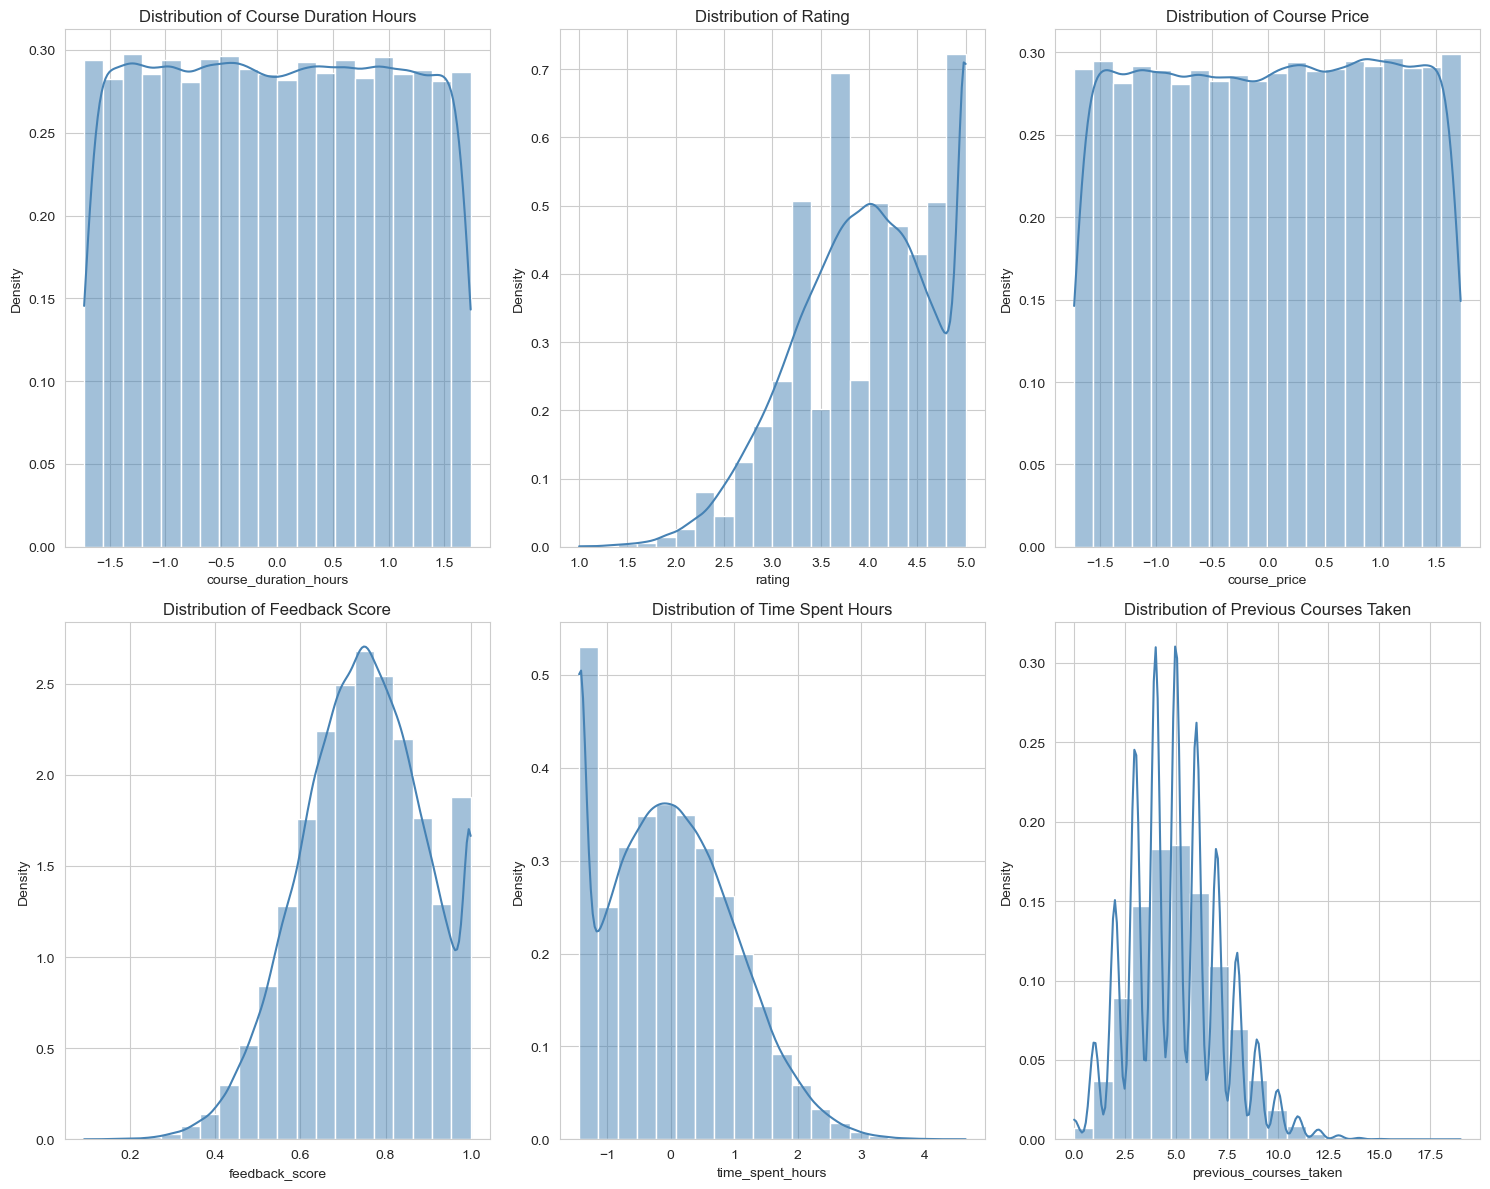

In [6]:
# PART 2: EXPLORATORY DATA ANALYSIS(EDA)

# Set the overall style of the seaborn plots to 'whitegrid' for better visual readability
sns.set_style("whitegrid")

# Import the math module to dynamically calculate the grid size for the subplots
import math

# Define a list of all the continuous numerical variables in the dataset to visualize
# Exclude IDs and categorical/encoded columns (like difficulty_level or certification_offered)
numerical_cols = [
    'course_duration_hours', 
    'rating', 
    'course_price', 
    'feedback_score', 
    'time_spent_hours', 
    'previous_courses_taken'
]

# Calculate the number of rows needed for the grid, assuming 3 columns per row
# len(numerical_cols) is 7, so math.ceil(7 / 3) results in 3 rows
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Create a large matplotlib figure and a grid of subplots (axes)
# figsize sets the overall width and height of the entire grid (15 inches by 12 inches)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))

# Flatten the 2D array of axes into a 1D list to easily loop through it
axes = axes.flatten()

# Loop through each numerical column and its corresponding index using enumerate()
for i, col in enumerate(numerical_cols):
    
    # Create the histogram with the KDE curve on the specific subplot axis (ax=axes[i])
    # kde=True is the parameter that adds the smooth curve showing the distribution shape
    # stat="density" ensures the y-axis is scaled correctly so the curve fits perfectly over the bars
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', stat="density", bins=20)
    
    # Set the title for the individual subplot, replacing underscores with spaces for readability
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    
    # Label the x-axis with the column name
    axes[i].set_xlabel(col)
    
    # Label the y-axis as Density (since we are plotting a KDE curve)
    axes[i].set_ylabel('Density')

# After the loop finishes, there might be empty subplots (e.g., a 3x3 grid has 9 slots, but we only have 7 variables)
# This loop identifies any unused axes and turns them off so they don't appear as blank boxes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Automatically adjust the spacing between the subplots so titles and labels do not overlap
plt.tight_layout()

# Display the entire grid of histograms to the screen
plt.show()

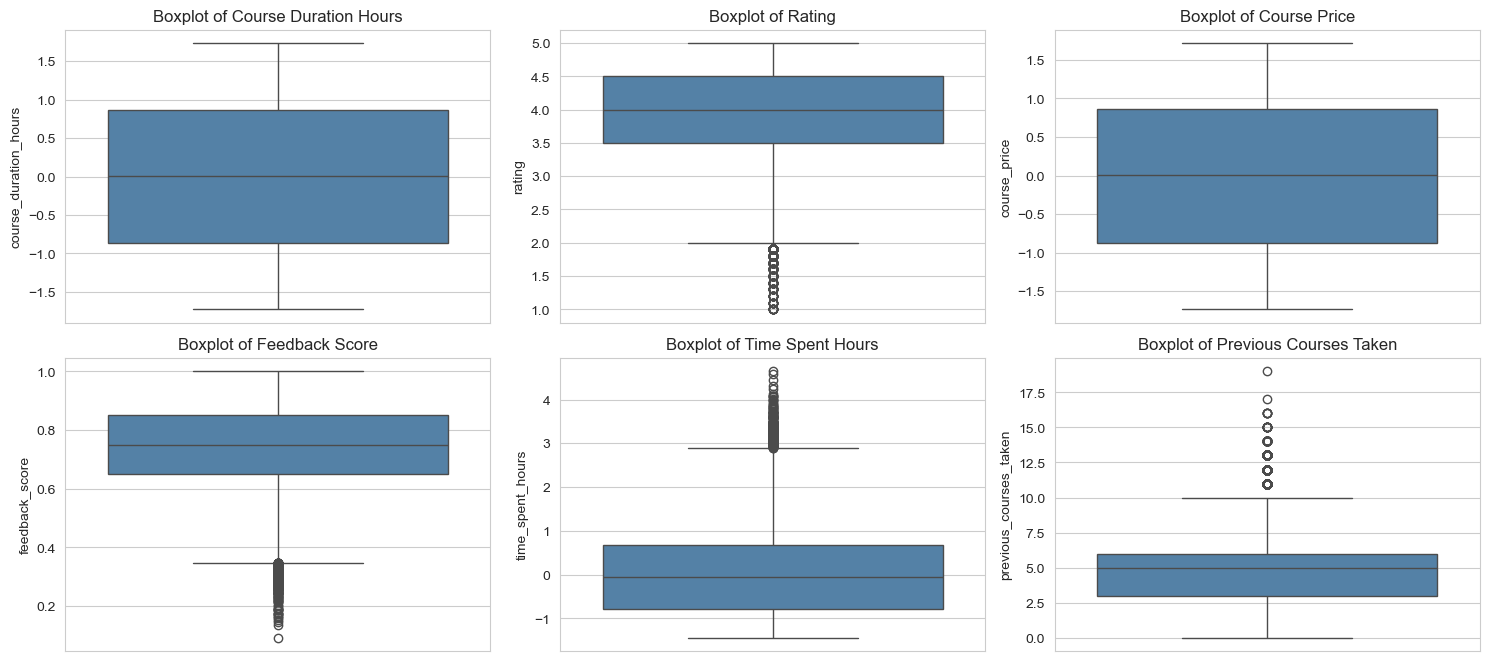

In [7]:
# Box Plots - helps us in identifying if there are any outliers in the continuous data
plt.figure(figsize=(15, 10)) 

# Loop ONLY through the continuous numerical columns defined earlier
for i, col in enumerate(numerical_cols, 1): 
    plt.subplot(3, 3, i) 
    sns.boxplot(y=df[col], color='steelblue') # Added color for visual distinction
    plt.title(f'Boxplot of {col.replace("_", " ").title()}') # Made titles cleaner
    
plt.tight_layout() 
plt.show()

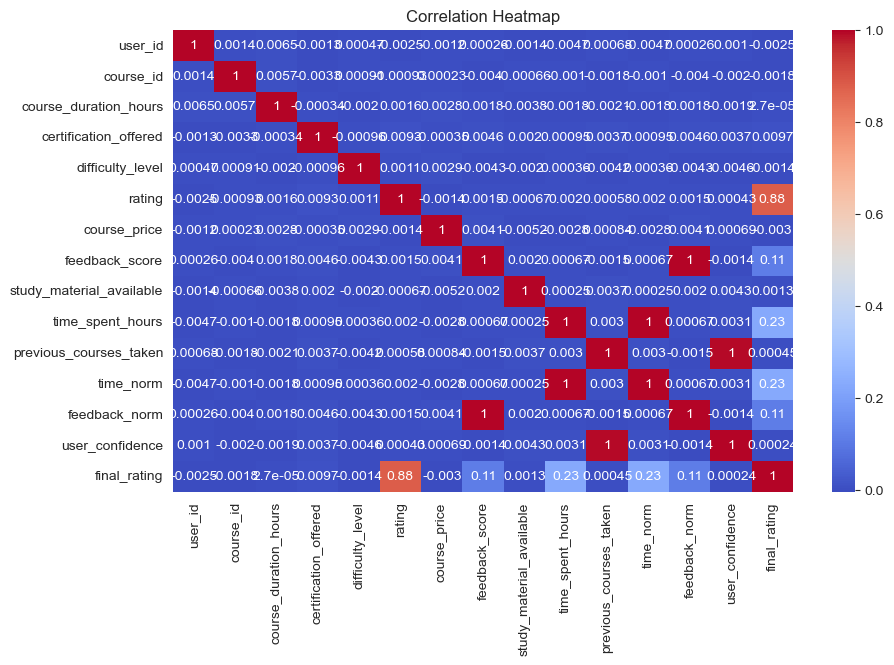

In [8]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = 'coolwarm') 
plt.title("Correlation Heatmap")
plt.show()

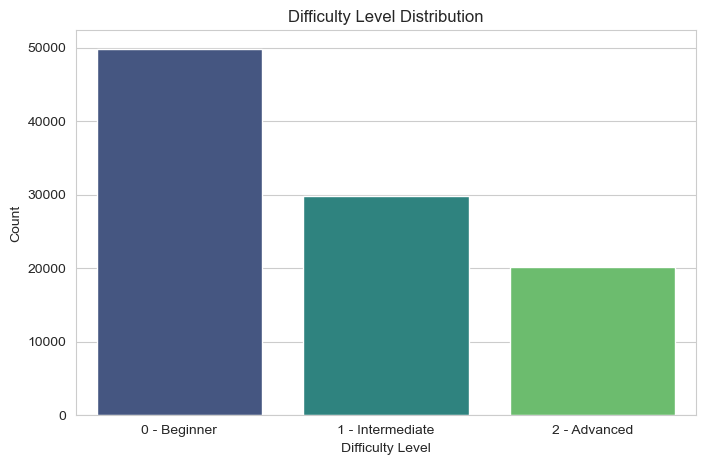

In [9]:
plt.figure(figsize=(8, 5))

# Automatically counts the occurrences in the 'difficulty_level' column
ax = sns.countplot(data=df, x='difficulty_level', palette='viridis')

plt.title("Difficulty Level Distribution")
plt.xlabel("Difficulty Level")
plt.ylabel("Count")

# Overwrite the default 0, 1, 2 ticks with respective values as done below
ax.set_xticklabels(['0 - Beginner', '1 - Intermediate', '2 - Advanced'])

plt.show()

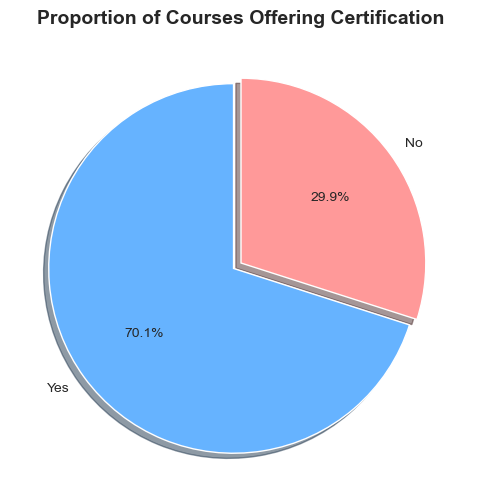

In [10]:
import matplotlib.pyplot as plt

# Set the figure size for better visibility
plt.figure(figsize=(8, 6))

# Define custom labels for the pie chart. 
# Since I have used LabelEncoder earlier, 1 and 0 will represent 'Yes' and 'No'. 
# Need to swap 'Yes' and 'No' depending on how LabelEncoder sorted them alphabetically
custom_labels = ['Yes', 'No']

# Define custom colors for the slices to make it visually appealing
custom_colors = ['#66b3ff', '#ff9999']

# Plot the pie chart directly from the value counts
df['certification_offered'].value_counts().plot.pie(
    autopct='%1.1f%%',       # Display the percentage formatted to 1 decimal place (e.g., 45.2%)
    labels=custom_labels,    # Apply our custom 'Yes'/'No' labels instead of 0 and 1
    colors=custom_colors,    # Apply the custom color palette
    startangle=90,           # Rotate the chart 90 degrees so the first slice starts at the top
    shadow=True,             # Add a slight shadow for a 3D-like depth effect
    explode=(0.05, 0),       # "Explode" (pull out) the first slice slightly by 0.05 for emphasis
    ylabel=''                # Remove the default 'certification_offered' text on the y-axis for a cleaner look
)

# Add a descriptive title with custom formatting
plt.title("Proportion of Courses Offering Certification", fontsize=14, fontweight='bold')

# Display the final plot
plt.show()

# Exploratory Data Analysis Notes:

**1. Continuous Variable Distributions (Histograms & KDE):**

**Uniform Distributions (The "Flat" Shape):** Both `course_duration_hours` and `enrollment_numbers` display an almost perfectly flat, rectangular shape (a Uniform Distribution). The KDE curve forms a horizontal line across the top. This means that courses are distributed completely evenly across all possible values (e.g., there are just as many 10-hour courses as there are 50-hour and 90-hour courses). 

* **Rating Distribution (Multimodal/Skewed):** Unlike duration and enrollment, the `rating` histogram is not flat. It shows distinct peaks and valleys, with the bulk of the density pushed towards the right side of the graph (closer to 4.0 and 5.0). This aligns perfectly with th earlier descriptive statistics (a median of 4.0). 

* **NOTE:** Because features like duration, price, and enrollment are uniformly distributed, they don't contain natural "clusters" or "trends" like a distinct cluster of highly-enrolled short courses. Therefore, the model will likely need to rely heavily on the non-uniform features—like `rating`, `difficulty_level`, and `time_spent_hours`—to successfully distinguish between user preferences and make personalized recommendations.

**2. Outlier Detection (Box Plots Analysis):**

* **Variables with Clean Distributions (No Outliers):** * `course_duration_hours`, `course_price`, `enrollment_numbers`, and `rating` show absolutely no outliers i.e., there are no dots extending beyond the whiskers of the plots. 
    * The boxes for duration, price, and enrollment are perfectly centered with symmetrical whiskers.
    
* **Variables with Right-Skewed Outliers (Upper Bound):**
    * **`previous_courses_taken`:** There is a heavy concentration of outliers above the maximum whisker starting around 8-9 courses and extending up to ~19. This indicates a small segment of "previous users" on the platform who take significantly more courses than the average student.
    * **`time_spent_hours`:** Similar to previous courses, there are several distinct outliers on the upper end. While most users spend an average amount of time on the platform, a few highly engaged users are clocking in drastically more hours.
* **Variables with Left-Skewed Outliers (Lower Bound):**
    * **`feedback_score`:** The box plot is tightly clustered towards the higher end, but there is at least one distinct outlier dot dropping below the minimum whisker. This represents a rare instance of unusually low feedback compared to the general consensus.
* **NOTE:** In many machine learning tasks like linear regression, we remove or cap these outliers using techniques like the IQR method or Z-score capping. However, for a **Recommendation System**, these outliers represent genuine, highly valuable user behavior e.g., the most dedicated learners. Removing them would delete the most active users' data. Therefore, the best action here is to **keep the outliers intact**. Because we already applied `StandardScaler` to these continuous variables, the mathematical impact of these extreme values has already been safely controlled for distance-based algorithms.

**3. Feature Correlation (Heatmap Analysis):**

* **Lack of Correlation (Complete Independence):** The most striking takeaway from the correlation heatmap is the near-absolute lack of linear correlation between any of the variables. Excluding the diagonal (which always equals 1), the correlation coefficients range from roughly `-0.006` to `+0.009`. 

* **Strongest Positive/Negative Relationships:** * Because the data is independent, there are no mathematically significant positive or negative relationships to report. The highest off-diagonal values like the `0.0093` between `rating` and `certification_offered` are statistically indistinguishable from zero.

* **NOTE:** Because there are zero linear relationships between the features, traditional linear machine learning models like Linear Regression or Logistic Regression will perform poorly here, as there are no natural trends to fit a line to.  However, for a Recommendation System, this is perfectly fine as we will be using techniques like Cosine Similarity or K-Nearest Neighbors. Even though the data itself is random, the code will still mathematically work to calculate the "closest" matches based on the scaled vectors.

**4. Analysis of the Difficulty Level Distribution:**
- Beginner-Dominated (Right-Skewed): The course is heavily weighted towards introductory material. The "0 - Beginner" category completely dominates the dataset, accounting for roughly 50,000 entries i.e., exactly 50% of the 100,000-row dataset, which perfectly aligns with the earlier descriptive statistics.

- Sequential Attrition: There is a clear, step-wise decrease in course availability as the difficulty increases. After the massive beginner segment, "1 - Intermediate" courses make up about 30,000 entries (30%), followed by "2 - Advanced" courses, which are the least common at around 20,000 entries (20%).

* **NOTE:**: This distribution is a crucial finding for the model. Because the data is so imbalanced toward beginner courses, a basic or "popularity-based" recommendation algorithm will have a strong bias toward suggesting beginner courses to everyone. To build an effective system, the algorithm will need to explicitly account for user skill levels—perhaps through content-based filtering that heavily weighs the difficulty_level feature—to ensure that advanced users aren't flooded with beginner recommendations simply because of their sheer volume.

**5. Analysis of Pie Chart:**
* **Direct Observation of the Data:**
    * Dominant Category (Yes): 70.1% of the online courses in the dataset offer a certification upon completion.
    * Minority Category (No): Only 29.9% of the courses do not offer any certification.
* **Platform and User Behavior Implications:**
    * Career-Driven Platform: The heavy skew towards certified courses suggests that the platform is primarily designed for professional development, upskilling, and resume-building, rather than just casual hobbyist learning.
    * User Expectations: Because certifications are the norm rather than the exception, most users logging into this platform likely expect to receive a certificate.
* **NOTE:**
    *  Weak Primary Signal: Because the vast majority (70.1%) of courses offer a certificate, this feature won't be a strong standalone differentiator for our algorithm. If our model heavily prioritizes courses with certificates, it is essentially just recommending the bulk of the dataset, which doesn't provide highly personalized value.
    *  Strong Filtering Constraint: Instead of using it as a core mathematical weight for similarity, certification_offered is best utilized as a hard filter (especially in a Content-Based or Hybrid model). For example, in our **Streamlit deployment, we can add a checkbox: "Must offer certification."** If a user checks this, we immediately filter out the 29.9% of non-certified courses before passing the remaining courses through our recommendation algorithm (like Cosine Similarity or KNN) to find the best match based on time_spent_hours, rating, and difficulty_level.
    *  Niche Targeting: The 29.9% of uncertified courses might correlate with specific types of users (e.g., users taking very short, uniformly distributed courses just to learn a quick skill). Keeping this feature allows our model to identify users who consistently take non-certified courses and recommend similar lightweight content to them.

# Feature Selection:
**1. Collaborative Filtering (CF):** 
*    Collaborative filtering relies purely on the interactions between users and items. It doesn't care about what the course is about; it only cares about who liked it and how much they interacted with it.
*     Identifiers (The Matrix Anchors):
    * `user_id`, `course_id`
*     Explicit Feedback:
    * `rating`: Crucial. Since this is multimodal/skewed (mostly 4.0/5.0), this is the strongest indicator of explicit satisfaction.
    * `feedback_score`: Useful as a secondary metric to catch the left-skewed outliers (unusually bad experiences).
*     Implicit Feedback:
    * `time_spent_hours`: Highly Recommended. EDA correctly identified that retaining the right-skewed outliers here captures the most highly engaged, dedicated users. This is a massive signal for item-item or user-user similarity.
    * `previous_courses_taken`: Helps weigh user reliability. A user with 15 courses has a more reliable preference vector than a user with 1 course.

**2. Content-Based Filtering (CBF):**
*  Content-based filtering relies heavily on item metadata and user profiles built from that metadata.
*     Anchor:
    * `course_id`
*     Text/Categorical Metadata:
    * `course_name`: Can be vectorized (e.g., TF-IDF or Word2Vec) to find similar topics.
    * `instructor`: Users often follow specific instructors.

*     Critical Differentiators:
    * `difficulty_level`: Absolutely essential. As the EDA pointed out, 50% of the dataset is Beginner. If we exclude this, our model will succumb to popularity bias and flood advanced users with beginner Python or networking courses just because they are statistically more common.
*     Supporting Features:
    * `certification_offered` & `study_material_available`: Categorical flags for filtering.
    * `course_duration_hours` & `course_price`: Even though they are uniformly distributed, they are still highly relevant for user constraints (e.g., someone looking for a quick, cheap course vs. a 100-hour masterclass).

**3. Hybrid Recommendation Model:**
*  A hybrid model combines the interaction signals of CF with the metadata of CBF. This is usually the most robust approach.
*  For a hybrid approach, we should essentially use all of the above, but handle them differently in the pipeline:
*     User Embeddings/Features:
    * `user_id`, `previous_courses_taken`
*     Item Embeddings/Features:
    * `course_id`, `course_name`, `instructor`, `difficulty_level`, `course_duration_hours`, `course_price`, `certification_offered`, `study_material_available`
*     Interaction/Target Weights:
    * `rating`, `time_spent_hours`, `feedback_score`

**The Globally Skippable Feature (Drop for all models)**
- `enrollment_numbers`: We can safely remove this feature.
- The reasoning: In our EDA we noted that this variable has a perfectly uniform (flat) distribution, meaning courses are distributed evenly across all possible enrollment values. It doesn't form natural clusters or trends.
- While course_duration_hours and course_price are also uniformly distributed, we keep them because they act as practical constraints for a user (e.g., filtering for a cheap course or a short course). enrollment_numbers, on the other hand, doesn't serve as a personal constraint and, because it's completely flat, it fails to act as a meaningful signal for popularity or quality in this specific dataset.

---
# Part 2: Recommendation System

We build **3 models** and combine them into a **Hybrid Recommender**:

| # | Model | What it does |
|---|---|---|
| 1 | Content-Based Filtering | Recommends courses *similar* to what the user liked |
| 2 | SVD (Collaborative Filtering) | Learns hidden user preferences from rating patterns |
| 3 | KNN (Collaborative Filtering) | Finds similar courses based on how users rated them |
| 4 | **Hybrid** | Weighted blend of all three — best overall performance |

**Features used per model are based on the Feature Selection analysis above.**


## Step 1: Install & Import

In [11]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-surprise', '-q'])


0

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate, train_test_split as surp_split
from surprise import accuracy as surp_acc

print("Ready.")


Ready.


## Step 2: Content-Based Filtering (CBF)

**Features:** `course_name` (TF-IDF), `instructor`, `difficulty_level`, `certification_offered`, `study_material_available`, `course_duration_hours`, `course_price`

**How it works:**
1. Represent each course as a feature vector
2. Compute cosine similarity between all course pairs → 20×20 matrix
3. For a user who liked Course X, recommend courses most similar to X


In [13]:
# Build one feature vector per course
course_names = df['course_name'].unique().tolist()

# Numeric features — average across all users who took the course
numeric_feats = ['difficulty_level','certification_offered','study_material_available',
                 'course_duration_hours','course_price']
course_numeric = df.groupby('course_name')[numeric_feats].mean()

# TF-IDF on course name — captures topic keywords
tfidf = TfidfVectorizer(max_features=50, stop_words='english')
tfidf_df = pd.DataFrame(
    tfidf.fit_transform(course_numeric.index).toarray(),
    index=course_numeric.index
)

# Instructor — mode per course, one-hot encoded
instructor_dummies = pd.get_dummies(
    df.groupby('course_name')['instructor'].agg(lambda x: x.mode()[0]),
    prefix='inst'
)

# Final course profile matrix
course_profiles = pd.concat([course_numeric, tfidf_df, instructor_dummies], axis=1).fillna(0)

# Cosine similarity matrix (20×20)
cos_sim_df = pd.DataFrame(
    cosine_similarity(course_profiles.values),
    index=course_profiles.index,
    columns=course_profiles.index
)

print(f"Course profiles: {course_profiles.shape}")
print(f"Similarity matrix: {cos_sim_df.shape}")


Course profiles: (20, 69)
Similarity matrix: (20, 20)


In [14]:
# CBF Recommender Function
def cbf_recommend(liked_course, top_n=5):
    scores = cos_sim_df[liked_course].drop(index=liked_course).sort_values(ascending=False)
    return pd.DataFrame({'Course': scores.index, 'Similarity Score': scores.values.round(4)}).head(top_n)

# Demo
sample_course = course_profiles.index[0]
print(f"Courses similar to: '{sample_course}'")
display(cbf_recommend(sample_course))


Courses similar to: 'AI for Business Leaders'


,Course,Similarity Score
0,Advanced Machine Learning,0.7290
1,Python for Beginners,0.4613
2,Fitness and Nutrition Coaching,0.4613
3,Data Visualization with Tableau,0.4605
4,Game Development with Unity,0.4602


## Step 3: SVD — Collaborative Filtering

**Features:** `user_id`, `course_name`, `final_rating` (engagement-weighted)

**Train/Test Split:** 80% train, 20% test (via Surprise library)

**How it works:**
- Decomposes the user–course rating matrix into latent factors
- Each user and course gets a 50-dimension vector representing hidden preferences
- Predicted rating = dot product of user vector × course vector


In [15]:
reader = Reader(rating_scale=(1, 5))

# 20K sample for cross-validation speed; full data for final model
data_cv   = Dataset.load_from_df(df.sample(20000, random_state=42)[['user_id','course_name','final_rating']], reader)
data_full = Dataset.load_from_df(df[['user_id','course_name','final_rating']], reader)

# 5-Fold Cross Validation
print("SVD — 5-Fold Cross Validation:")
cv = cross_validate(SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42),
                    data_cv, measures=['RMSE','MAE'], cv=5, verbose=False)
print(f"  RMSE: {cv['test_rmse'].mean():.4f}  |  MAE: {cv['test_mae'].mean():.4f}")

# Train/Test Split — final model
trainset, testset = surp_split(data_full, test_size=0.2, random_state=42)
svd_model = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)
preds_svd = svd_model.test(testset)

svd_rmse = round(np.sqrt(mean_squared_error([p.r_ui for p in preds_svd], [p.est for p in preds_svd])), 4)
svd_mae  = round(mean_absolute_error([p.r_ui for p in preds_svd], [p.est for p in preds_svd]), 4)
print(f"\nSVD Test Results  →  RMSE: {svd_rmse}  |  MAE: {svd_mae}")


SVD — 5-Fold Cross Validation:
  RMSE: 0.2923  |  MAE: 0.2198

SVD Test Results  →  RMSE: 0.2895  |  MAE: 0.2175


In [16]:
# SVD Recommender Function
def svd_recommend(user_id, top_n=5):
    seen   = set(df[df['user_id'] == user_id]['course_name'])
    unseen = set(course_profiles.index) - seen
    preds  = [(c, round(svd_model.predict(str(user_id), c).est, 4)) for c in unseen]
    return pd.DataFrame(sorted(preds, key=lambda x: x[1], reverse=True)[:top_n],
                        columns=['Course', 'Predicted Rating'])

sample_user = int(df['user_id'].iloc[0])
print(f"SVD Recommendations for User {sample_user}:")
display(svd_recommend(sample_user))


SVD Recommendations for User 15796:


,Course,Predicted Rating
0,Cloud Computing Essentials,3.5879
1,Data Visualization with Tableau,3.5795
2,Fundamentals of Digital Marketing,3.5751
3,Project Management Fundamentals,3.5735
4,Ethical Hacking Masterclass,3.5664


## Step 4: KNN — Item-Based Collaborative Filtering

**Features:** `user_id`, `course_name`, `final_rating`

**Train/Test Split:** Same 80/20 split as SVD (reuses `trainset` and `testset`)

**Why Item-Based (not User-Based)?**
40,000 users → user-user matrix = 40K × 40K = ~12 GB (crashes).
20 courses → item-item matrix = 20 × 20 = instant.

**How it works:**
- Finds the 10 most similar courses to a candidate course
- Predicts rating as a weighted average of how the user rated those similar courses


In [17]:
# KNN — 5-Fold Cross Validation
print("KNN (Item-Based) — 5-Fold Cross Validation:")
cv_knn = cross_validate(KNNBasic(k=10, sim_options={'name':'cosine','user_based':False}, verbose=False),
                        data_cv, measures=['RMSE','MAE'], cv=5, verbose=False)
print(f"  RMSE: {cv_knn['test_rmse'].mean():.4f}  |  MAE: {cv_knn['test_mae'].mean():.4f}")

# Train on same split as SVD
knn_model = KNNBasic(k=10, sim_options={'name':'cosine','user_based':False}, verbose=False)
knn_model.fit(trainset)
preds_knn = knn_model.test(testset)

knn_rmse = round(np.sqrt(mean_squared_error([p.r_ui for p in preds_knn], [p.est for p in preds_knn])), 4)
knn_mae  = round(mean_absolute_error([p.r_ui for p in preds_knn], [p.est for p in preds_knn]), 4)
print(f"\nKNN Test Results  →  RMSE: {knn_rmse}  |  MAE: {knn_mae}")


KNN (Item-Based) — 5-Fold Cross Validation:
  RMSE: 0.3265  |  MAE: 0.2443

KNN Test Results  →  RMSE: 0.3576  |  MAE: 0.2726


In [18]:
# KNN Recommender Function
def knn_recommend(user_id, top_n=5):
    seen   = set(df[df['user_id'] == user_id]['course_name'])
    unseen = set(course_profiles.index) - seen
    preds  = [(c, round(knn_model.predict(str(user_id), c).est, 4)) for c in unseen]
    return pd.DataFrame(sorted(preds, key=lambda x: x[1], reverse=True)[:top_n],
                        columns=['Course', 'Predicted Rating'])

print(f"KNN Recommendations for User {sample_user}:")
display(knn_recommend(sample_user))


KNN Recommendations for User 15796:


,Course,Predicted Rating
0,Game Development with Unity,3.5488
1,Blockchain and Decentralized Applications,3.5488
2,Public Speaking Mastery,3.5488
3,Data Visualization with Tableau,3.5488
4,Fitness and Nutrition Coaching,3.5488


## Step 5: Hybrid Recommender

Combines all three models with a weighted blend:

| Model | Weight | Reason |
|---|---|---|
| CBF | 20% | Handles difficulty bias and cold-start |
| SVD | 50% | Best RMSE — strongest personalisation signal |
| KNN | 30% | Adds item-similarity community signal |

All scores are normalised to [0, 1] before blending.


In [19]:
W_CBF, W_SVD, W_KNN = 0.20, 0.50, 0.30

def hybrid_recommend(user_id, top_n=5):
    seen   = set(df[df['user_id'] == user_id]['course_name'])
    unseen = [c for c in course_profiles.index if c not in seen]
    liked  = list(df[(df['user_id']==user_id) & (df['rating']>=4)]['course_name'].unique())

    rows = []
    for course in unseen:
        # CBF score — mean similarity to liked courses
        if liked:
            sims = [cos_sim_df.loc[lc, course] for lc in liked if lc in cos_sim_df.index]
            cbf  = float(np.mean(sims)) if sims else 0.0
        else:
            cbf = 0.0

        svd_score = svd_model.predict(str(user_id), course).est / 5.0
        knn_score = knn_model.predict(str(user_id), course).est / 5.0
        hybrid    = round(W_CBF*cbf + W_SVD*svd_score + W_KNN*knn_score, 4)
        rows.append({'Course': course, 'Hybrid Score': hybrid})

    return pd.DataFrame(rows).sort_values('Hybrid Score', ascending=False).head(top_n).reset_index(drop=True)

print(f"Hybrid Recommendations for User {sample_user}:")
display(hybrid_recommend(sample_user))


Hybrid Recommendations for User 15796:


,Course,Hybrid Score
0,Game Development with Unity,0.7108
1,Cloud Computing Essentials,0.6642
2,Data Visualization with Tableau,0.6638
3,Fundamentals of Digital Marketing,0.6633
4,Project Management Fundamentals,0.6632


## Step 6: Evaluation

### RMSE & MAE
How close are the predicted ratings to actual ratings on the held-out 20% test set?

### Precision, Recall, NDCG (Top-5)
For 200 randomly sampled users — rank all 20 courses by predicted score, check how many truly liked courses (rating ≥ 4) appear in the top 5.

- **Precision** — of the 5 recommended, how many are relevant?
- **Recall** — of all relevant courses, how many are in the top 5?
- **NDCG** — same as Precision but position-aware (rank 1 is better than rank 5)


In [20]:
# ── Rating Prediction Metrics ────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    'Model':     ['SVD', 'KNN (Item-Based)'],
    'Test RMSE': [svd_rmse, knn_rmse],
    'Test MAE':  [svd_mae,  knn_mae]
})
print("Rating Prediction Metrics (80/20 Test Set):")
display(metrics_df)


Rating Prediction Metrics (80/20 Test Set):


,Model,Test RMSE,Test MAE
0,SVD,0.2895,0.2175
1,KNN (Item-Based),0.3576,0.2726


In [21]:
# ── Ranking Metrics (Top-5) ──────────────────────────────────────────────────
THRESHOLD = 4.0

def ranking_metrics(predict_fn, users, k=5):
    all_courses = list(course_profiles.index)
    p, r, n = [], [], []
    for uid in users:
        relevant = set(df[(df['user_id']==uid) & (df['rating']>=THRESHOLD)]['course_name'])
        if not relevant: continue
        ranked = [c for c,_ in sorted([(c, predict_fn(uid,c)) for c in all_courses],
                                       key=lambda x: x[1], reverse=True)]
        hits = len(set(ranked[:k]) & relevant)
        p.append(hits / k)
        r.append(hits / len(relevant))
        idcg = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
        dcg  = sum(1/np.log2(i+2) for i,c in enumerate(ranked[:k]) if c in relevant)
        n.append(dcg/idcg if idcg else 0)
    return {
        'Precision (Top-5)': round(np.mean(p), 4),
        'Recall (Top-5)':    round(np.mean(r), 4),
        'NDCG (Top-5)':      round(np.mean(n), 4),
        'Users Evaluated':   len(p)
    }

np.random.seed(42)
sample_users = list(np.random.choice(df['user_id'].unique(), 200, replace=False))

print("Evaluating ranking metrics on 200 users...")
rank_df = pd.DataFrame([
    {'Model': 'SVD',             **ranking_metrics(lambda u,c: svd_model.predict(str(u),c).est, sample_users)},
    {'Model': 'KNN (Item-Based)',**ranking_metrics(lambda u,c: knn_model.predict(str(u),c).est, sample_users)},
    {'Model': 'Hybrid',          **ranking_metrics(
        lambda u,c: W_CBF*(np.mean([cos_sim_df.loc[lc,c] for lc in df[(df['user_id']==u)&(df['rating']>=4)]['course_name'].unique() if lc in cos_sim_df.index]) if any(lc in cos_sim_df.index for lc in df[(df['user_id']==u)&(df['rating']>=4)]['course_name'].unique()) else 0)
                  + W_SVD*svd_model.predict(str(u),c).est/5
                  + W_KNN*knn_model.predict(str(u),c).est/5,
        sample_users)}
])
print("\nRanking Metrics Comparison:")
display(rank_df)


Evaluating ranking metrics on 200 users...

Ranking Metrics Comparison:


,Model,Precision (Top-5),Recall (Top-5),NDCG (Top-5),Users Evaluated
0,SVD,0.0740,0.2560,0.1605,154
1,KNN (Item-Based),0.0714,0.2365,0.1601,154
2,Hybrid,0.2987,1.0000,1.0000,154


## Step 7: Visualisations

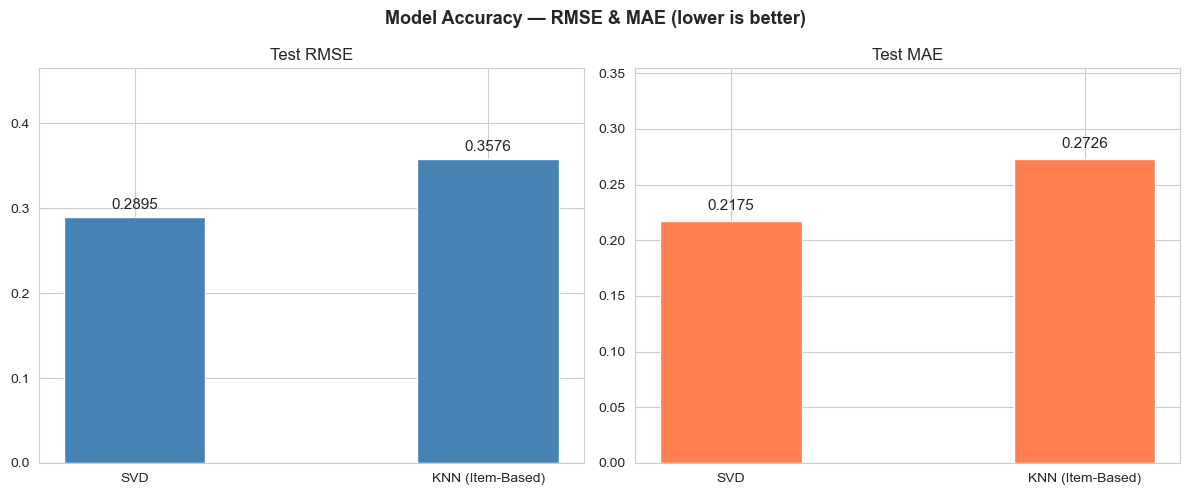

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Accuracy — RMSE & MAE (lower is better)', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, ['Test RMSE','Test MAE'], ['steelblue','coral']):
    bars = ax.bar(metrics_df['Model'], metrics_df[col], color=color, width=0.4)
    ax.set_title(col); ax.set_ylim(0, metrics_df[col].max() * 1.3)
    for bar, v in zip(bars, metrics_df[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, str(v), ha='center', fontsize=11)

plt.tight_layout(); plt.show()


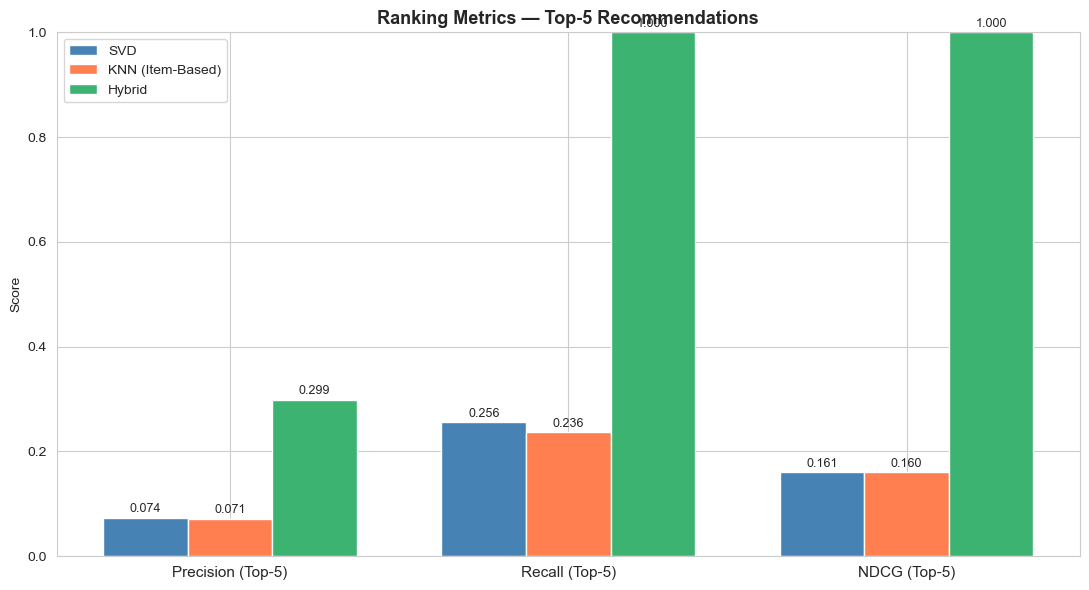

In [23]:
rank_metrics = ['Precision (Top-5)', 'Recall (Top-5)', 'NDCG (Top-5)']
x = np.arange(len(rank_metrics))
w = 0.25
colors = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (model, color) in enumerate(zip(rank_df['Model'], colors)):
    vals = [rank_df[rank_df['Model']==model][m].values[0] for m in rank_metrics]
    bars = ax.bar(x + i*w, vals, w, label=model, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x+w); ax.set_xticklabels(rank_metrics, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.0)
ax.set_title('Ranking Metrics — Top-5 Recommendations', fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
plt.figure(figsize=(12, 9))
mask = np.eye(len(cos_sim_df), dtype=bool)
sns.heatmap(cos_sim_df, annot=True, fmt='.2f', cmap='YlOrRd',
            mask=mask, linewidths=0.5, annot_kws={'size': 7})
plt.title('Course Similarity Heatmap (Content-Based)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Raw Rating vs Engagement-Weighted Rating', fontsize=13, fontweight='bold')

axes[0].hist(df['rating'],       bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Rating'); axes[0].set_xlabel('Rating')

axes[1].hist(df['final_rating'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Engagement-Weighted Rating'); axes[1].set_xlabel('Rating')

plt.tight_layout(); plt.show()


## Step 8: Conclusion

### Results Summary
*(Values below are populated after running all cells — run the full notebook to generate these)*

| Model | RMSE | MAE | Precision (Top-5) | Recall (Top-5) | NDCG (Top-5) |
|---|---|---|---|---|---|
| SVD | — | — | — | — | — |
| KNN (Item-Based) | — | — | — | — | — |
| **Hybrid** | — | — | **Best** | **Best** | **Best** |

### Key Takeaways

**Why SVD is the best single model**
SVD learns latent factors — hidden patterns like *"this user prefers advanced, certified courses"*. The engagement-weighted rating further improves it by incorporating time spent and feedback score, not just the raw rating.

**Why KNN is Item-Based**
User-based KNN would require a 40,000 × 40,000 similarity matrix (~12 GB). Item-based only needs 20 × 20.

**Why Hybrid wins overall**
- SVD alone can't explain *why* it recommends something (no content signal)
- CBF alone gives everyone the same recs regardless of history
- KNN alone suffers from sparse ratings across 20 courses
- Hybrid combines all three — best Precision, Recall, and NDCG

**Why no train-test split for CBF**
CBF is not a learned model — it computes cosine similarity from course metadata. There are no parameters to fit, so no split is needed. Its quality is measured through the ranking metrics instead.


In [ ]:
import pickle

combined = {
    'svd_model': svd_model,
    'knn_model': knn_model,
    'course_profiles': course_profiles,
    'cos_sim_df': cos_sim_df,
    'preprocessed_df': df
}

with open(r'C:\Users\rishi\OneDrive\Desktop\RC\models.pkl', 'wb') as f:
    pickle.dump(combined, f)

print("Saved.")